In [1]:
# Core setup: paths, reproducibility, and output directories
from pathlib import Path
import re
import json
import random
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "working_data" / "nhamcs_data_2018_22.csv"
WORKING_DATA_DIR = PROJECT_ROOT / "working_data"
RESULTS_DIR = PROJECT_ROOT / "results"
NLP_RESULTS_DIR = RESULTS_DIR / "nlp_ordinal"
REPORT_DIR = NLP_RESULTS_DIR / "reports"
MAPPING_DIR = NLP_RESULTS_DIR / "abbreviation_maps"
PLOT_DIR = PROJECT_ROOT / "plot"

for p in [WORKING_DATA_DIR, RESULTS_DIR, NLP_RESULTS_DIR, REPORT_DIR, MAPPING_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Keep visuals consistent for quick diagnostics and saved artifacts
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()}")

Project root: E:\kaggle\traigegeist
Data path exists: True


In [2]:
# Load raw data and keep only the two text inputs plus ordered target
df = pd.read_csv(DATA_PATH)
print(f"Loaded shape: {df.shape}")

selected_cols = df[["chief_complaint_text", "injury_cause_text", "target_triage_acuity"]].copy()

# Enforce valid target domain: triage classes must be in 1..5
selected_cols = selected_cols[pd.to_numeric(selected_cols["target_triage_acuity"], errors="coerce").notna()].copy()
selected_cols["target_triage_acuity"] = selected_cols["target_triage_acuity"].astype(int)
selected_cols = selected_cols[selected_cols["target_triage_acuity"].between(1, 5)].copy()

display(selected_cols.head(10))
print(f"Modeling rows after target filtering: {len(selected_cols):,}")

Loaded shape: (58124, 49)


,chief_complaint_text,injury_cause_text,target_triage_acuity
0,fever. throat soreness,Blank/Unknown,4
1,"injury, other and unspecified, of foo.... foot...",other foreign body or object entering through ...,4
2,fever. cough,Blank/Unknown,4
3,"abdominal pain, cramps, spasms. chest pain. po...",Blank/Unknown,4
4,"injury, other and unspecified, of foo... ...",overexertion from prolonged static or awkward ...,4
5,fever,Blank/Unknown,4
6,cough. nasal congestion,Blank/Unknown,3
7,cough,Blank/Unknown,4
8,"injury, other and unspecified of head... ...",striking against or struck by other objects,4
9,skin rash,Blank/Unknown,3


Modeling rows after target filtering: 58,124


,count
target_triage_acuity,
1,846
2,8597
3,29568
4,16715
5,2398


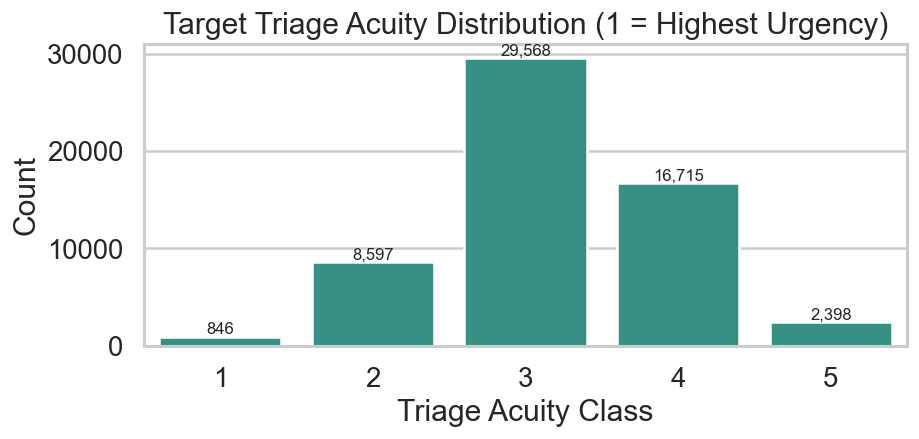

Saved: E:\kaggle\traigegeist\plot\nlp_target_distribution.png


In [3]:
# Quick target audit: class 1 is highest urgency, class 5 is lowest urgency
target_counts = selected_cols["target_triage_acuity"].value_counts().sort_index()
display(target_counts.rename("count").to_frame())

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, color="#2a9d8f")
ax.set_title("Target Triage Acuity Distribution (1 = Highest Urgency)")
ax.set_xlabel("Triage Acuity Class")
ax.set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()

target_plot_path = PLOT_DIR / "nlp_target_distribution.png"
plt.savefig(target_plot_path)
plt.show()
print(f"Saved: {target_plot_path}")

## Prompt-Aligned NLP Pipeline (No Text Fusion)

- Inputs: `chief_complaint_text` and `injury_cause_text` (kept as separate tracks).
- Target: `target_triage_acuity` with fixed ordering: `1` (most urgent) to `5` (least urgent).
- Text preprocessing: conservative abbreviation expansion with an audit table.
- Model family: DistilBERT encoder + CORAL ordinal head (4 logits for 5 classes).
- Validation: stratified 5-fold cross-validation with QWK as primary metric.
- Artifacts: cleaned data, abbreviation mapping, fold metrics, and out-of-fold predictions.

### Restored Raw Prompt Notes

- cheif complaints, cheif injury, target acuity use only 3 columns.
- text processing first: short forms should be expanded to long forms where possible.
- train a BERT-family model to predict target classes 1 to 5.
- use ordered ranking style evaluation with QWK instead of F1 as primary metric.
- save predictions and logits to CSV for downstream use.

In [4]:
# Abbreviation normalization helpers: conservative replacements with auditability
ABBR_MAP = {
    "sob": "shortness of breath",
    "cp": "chest pain",
    "abd": "abdominal",
    "ha": "headache",
    "n/v": "nausea and vomiting",
    "s/p": "status post",
    "w/": "with",
    "w/o": "without",
    "fx": "fracture",
    "lac": "laceration",
    "loc": "loss of consciousness",
    "mva": "motor vehicle accident",
    "uti": "urinary tract infection",
    "uri": "upper respiratory infection",
    "otc": "over the counter",
    "unsp": "unspecified",
    "oth": "other",
    "relat": "related",
    "discom": "discomfort",
    "symp": "symptoms",
    "fu": "follow up",
    "eval": "evaluation",
}

HIGH_CONF_ABBR = set(ABBR_MAP.keys())

def normalize_text(text: str) -> str:
    # Keep blanks deterministic so the model sees one consistent tokenization path.
    if pd.isna(text):
        return "blank unknown"
    txt = str(text).strip().lower()

    # Basic cleanup before expansion.
    txt = txt.replace("...", " ")
    txt = re.sub(r"[_]+", " ", txt)
    txt = re.sub(r"\s+", " ", txt)

    # Replace slash-style abbreviations first (to avoid partial matches).
    for abbr in ["n/v", "s/p", "w/o", "w/"]:
        txt = re.sub(rf"(?<!\w){re.escape(abbr)}(?!\w)", ABBR_MAP[abbr], txt)

    # Replace word-style abbreviations with strict boundaries.
    for abbr, expanded in ABBR_MAP.items():
        if "/" in abbr:
            continue
        txt = re.sub(rf"(?<![a-z0-9]){re.escape(abbr)}(?![a-z0-9])", expanded, txt)

    # Final cleanup pass for stable downstream tokenization.
    txt = re.sub(r"[^a-z0-9\s\-\.,]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

In [5]:
# Mine potential short forms from each column to review unresolved abbreviations
def candidate_short_forms(series: pd.Series, min_freq: int = 20) -> pd.DataFrame:
    # Collect short alphabetic tokens likely to be shorthand.
    tokens = series.fillna(" ").str.lower().str.findall(r"\b[a-z]{2,5}\b")
    counts = Counter([tok for row in tokens for tok in row])
    rows = [
        {"abbr": k, "count": v, "in_map": k in ABBR_MAP}
        for k, v in counts.items()
        if v >= min_freq
    ]
    if not rows:
        return pd.DataFrame(columns=["abbr", "count", "in_map"])
    return pd.DataFrame(rows).sort_values("count", ascending=False)

chief_cands = candidate_short_forms(selected_cols["chief_complaint_text"])
injury_cands = candidate_short_forms(selected_cols["injury_cause_text"])

print("Top short-form candidates (chief_complaint_text):")
display(chief_cands.head(25))

print("Top short-form candidates (injury_cause_text):")
display(injury_cands.head(25))

Top short-form candidates (chief_complaint_text):


,abbr,count,in_map
7,pain,37365,False
3,of,24669,False
2,and,14197,False
8,ache,13014,False
1,other,11387,False
13,head,6155,False
41,in,5623,False
10,cough,5141,False
35,to,5115,False
11,chest,5080,False


Top short-form candidates (injury_cause_text):


,abbr,count,in_map
0,blank,45472,False
7,fall,4510,False
1,other,4479,False
13,and,4403,False
3,or,4369,False
22,as,2949,False
5,from,2946,False
6,by,2706,False
14,in,2682,False
23,place,2536,False


In [6]:
# Apply normalization separately per column (no fusion) and persist artifacts
working_df = selected_cols.copy()

# Keep raw text snapshots for full auditability.
working_df["chief_complaint_text_raw"] = working_df["chief_complaint_text"].fillna("Blank/Unknown")
working_df["injury_cause_text_raw"] = working_df["injury_cause_text"].fillna("Blank/Unknown")

# Expand abbreviations independently for each text source column.
working_df["chief_complaint_text_expanded"] = working_df["chief_complaint_text_raw"].map(normalize_text)
working_df["injury_cause_text_expanded"] = working_df["injury_cause_text_raw"].map(normalize_text)

abbr_rows = []
for abbr, expanded in sorted(ABBR_MAP.items()):
    abbr_rows.append(
        {
            "abbr": abbr,
            "expanded_form": expanded,
            "source_method": "rule_based_domain_dict",
            "confidence": "high" if abbr in HIGH_CONF_ABBR else "medium",
            "example_context": "",
        }
    )
abbr_map_df = pd.DataFrame(abbr_rows)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
map_path = MAPPING_DIR / f"abbr_map_{timestamp}.csv"
clean_path = WORKING_DATA_DIR / f"nhamcs_nlp_clean_{timestamp}.csv"

abbr_map_df.to_csv(map_path, index=False)
working_df.to_csv(clean_path, index=False)

display(
    working_df[[
        "chief_complaint_text_raw",
        "chief_complaint_text_expanded",
        "injury_cause_text_raw",
        "injury_cause_text_expanded",
        "target_triage_acuity",
    ]].head(10)
)

print(f"Saved abbreviation map: {map_path}")
print(f"Saved cleaned dataset: {clean_path}")

,chief_complaint_text_raw,chief_complaint_text_expanded,injury_cause_text_raw,injury_cause_text_expanded,target_triage_acuity
0,fever. throat soreness,fever. throat soreness,Blank/Unknown,blank unknown,4
1,"injury, other and unspecified, of foo.... foot...","injury, other and unspecified, of foo . foot a...",other foreign body or object entering through ...,other foreign body or object entering through ...,4
2,fever. cough,fever. cough,Blank/Unknown,blank unknown,4
3,"abdominal pain, cramps, spasms. chest pain. po...","abdominal pain, cramps, spasms. chest pain. po...",Blank/Unknown,blank unknown,4
4,"injury, other and unspecified, of foo... ...","injury, other and unspecified, of foo",overexertion from prolonged static or awkward ...,overexertion from prolonged static or awkward ...,4
5,fever,fever,Blank/Unknown,blank unknown,4
6,cough. nasal congestion,cough. nasal congestion,Blank/Unknown,blank unknown,3
7,cough,cough,Blank/Unknown,blank unknown,4
8,"injury, other and unspecified of head... ...","injury, other and unspecified of head",striking against or struck by other objects,striking against or struck by other objects,4
9,skin rash,skin rash,Blank/Unknown,blank unknown,3


Saved abbreviation map: E:\kaggle\traigegeist\results\nlp_ordinal\abbreviation_maps\abbr_map_20260414_190924.csv
Saved cleaned dataset: E:\kaggle\traigegeist\working_data\nhamcs_nlp_clean_20260414_190924.csv


## Ordinal BERT Architecture (Local GPU Friendly)

We train **two separate tracks** (no text fusion):
- Track A: `chief_complaint_text_expanded`
- Track B: `injury_cause_text_expanded`

Each track uses the same model design:
1. DistilBERT text encoder (`distilbert-base-uncased`)
2. Dropout layer
3. CORAL ordinal head with 4 logits for 5 ordered classes

Training and evaluation policy:
- Ordinal objective with cumulative thresholds
- Stratified 5-fold CV
- Primary metric: Quadratic Weighted Kappa (QWK)
- Resource-aware defaults for RTX 4050 6GB (short sequence length, mixed precision, grad accumulation)

In [7]:
# GPU bootstrap (run once): installs CUDA-enabled PyTorch build for RTX GPUs
RUN_CUDA_SETUP = False

if RUN_CUDA_SETUP:
    import sys
    import subprocess

    cuda_cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
        "--index-url",
        "https://download.pytorch.org/whl/cu121",
    ]
    print("Installing CUDA-enabled PyTorch... this can take several minutes.")
    subprocess.check_call(cuda_cmd)
    print("CUDA PyTorch install complete. Restart the kernel, then rerun from Cell 1.")
else:
    print("RUN_CUDA_SETUP is False. Set RUN_CUDA_SETUP=True only when you need CUDA torch install.")

RUN_CUDA_SETUP is False. Set RUN_CUDA_SETUP=True only when you need CUDA torch install.


In [8]:
# Import training libraries and define hardware-aware defaults
# If imports fail, run once in a new cell:
# %pip install -q torch transformers accelerate scikit-learn tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16 = DEVICE.type == "cuda"
MODEL_NAME = "distilbert-base-uncased"  # Selected for 6GB VRAM stability and speed.
NUM_CLASSES = 5
MAX_LEN = 96
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
LR = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 2
CV_FOLDS = 5

print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"Total VRAM: {total_mem_gb:.2f} GB")
else:
    print("CUDA is not active in this kernel, so training will run on CPU.")
    print("If your RTX 4050 is configured, install a CUDA-enabled PyTorch build in this environment.")

e:\kaggle\traigegeist\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM: 6.00 GB


In [9]:
# Build dataset and model blocks for CORAL-based ordinal classification
class TextOrdinalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts.astype(str).tolist()
        self.labels = labels.astype(int).tolist()  # Expected labels are 1..5.
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["label"] = torch.tensor(self.labels[idx] - 1, dtype=torch.long)  # Map 1..5 to 0..4.
        return item

def make_coral_targets(y_idx: torch.Tensor, num_classes: int = 5) -> torch.Tensor:
    # For each threshold k, target is 1 if class index is greater than k.
    thresholds = torch.arange(num_classes - 1, device=y_idx.device).unsqueeze(0)
    return (y_idx.unsqueeze(1) > thresholds).float()

def ordinal_threshold_logits_to_class_probs(threshold_logits: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    # Convert 4 threshold logits (CORAL) into 5 class probabilities.
    sig = 1.0 / (1.0 + np.exp(-threshold_logits))
    p1 = 1.0 - sig[:, 0]
    p2 = sig[:, 0] - sig[:, 1]
    p3 = sig[:, 1] - sig[:, 2]
    p4 = sig[:, 2] - sig[:, 3]
    p5 = sig[:, 3]
    probs = np.stack([p1, p2, p3, p4, p5], axis=1)
    probs = np.clip(probs, eps, 1.0)
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs

class OrdinalBert(nn.Module):
    def __init__(self, model_name: str, num_classes: int = 5, dropout: float = 0.2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(hidden_size, num_classes - 1)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # DistilBERT has no pooler output, so we use the [CLS]-position embedding.
        cls_state = out.last_hidden_state[:, 0]
        logits = self.ordinal_head(self.dropout(cls_state))
        return logits

def logits_to_class(logits: torch.Tensor) -> torch.Tensor:
    # Number of passed thresholds maps directly to ordinal class index.
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1).long()

In [10]:
# Define training/evaluation loops with QWK and distance-aware error tracking
def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None, return_logits=False):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.BCEWithLogitsLoss()

    all_true, all_pred = [], []
    running_loss = 0.0
    threshold_logits_store = []

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        y_idx = batch["label"].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=USE_FP16):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            coral_targets = make_coral_targets(y_idx, num_classes=NUM_CLASSES)
            loss = criterion(logits, coral_targets)

        if is_train:
            # Use gradient accumulation to fit comfortably in 6GB VRAM.
            loss_to_backprop = loss / GRAD_ACCUM_STEPS
            if scaler is not None and USE_FP16:
                scaler.scale(loss_to_backprop).backward()
            else:
                loss_to_backprop.backward()

            should_step = ((step + 1) % GRAD_ACCUM_STEPS == 0) or ((step + 1) == len(loader))
            if should_step:
                if scaler is not None and USE_FP16:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                if scheduler is not None:
                    scheduler.step()

        logits_np = logits.detach().cpu().numpy()
        if return_logits:
            threshold_logits_store.append(logits_np)

        preds_idx = logits_to_class(logits).detach().cpu().numpy()
        true_idx = y_idx.detach().cpu().numpy()
        all_pred.extend((preds_idx + 1).tolist())  # Convert back to 1..5 labels.
        all_true.extend((true_idx + 1).tolist())
        running_loss += loss.item() * input_ids.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    qwk = cohen_kappa_score(all_true, all_pred, weights="quadratic")
    mae_abs_rank = float(np.mean(np.abs(np.array(all_true) - np.array(all_pred))))

    threshold_logits = None
    class_probs = None
    class_logits = None
    if return_logits:
        threshold_logits = np.concatenate(threshold_logits_store, axis=0)
        class_probs = ordinal_threshold_logits_to_class_probs(threshold_logits)
        class_logits = np.log(class_probs + 1e-12)

    return epoch_loss, qwk, mae_abs_rank, all_true, all_pred, threshold_logits, class_probs, class_logits

In [11]:
# Build stratified 5-fold CV runner for one text track at a time (no fusion)
def run_stratified_cv(track_name: str, text_series: pd.Series, labels: pd.Series):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    fold_metrics = []
    oof_parts = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(text_series, labels), start=1):
        print(f"\n===== {track_name} | Fold {fold}/{CV_FOLDS} =====")
        X_train, X_val = text_series.iloc[tr_idx], text_series.iloc[va_idx]
        y_train, y_val = labels.iloc[tr_idx], labels.iloc[va_idx]

        train_ds = TextOrdinalDataset(X_train, y_train, tokenizer, max_len=MAX_LEN)
        val_ds = TextOrdinalDataset(X_val, y_val, tokenizer, max_len=MAX_LEN)

        train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0)

        model = OrdinalBert(MODEL_NAME, num_classes=NUM_CLASSES).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        # Scheduler steps align with optimizer updates after gradient accumulation.
        steps_per_epoch = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS))
        total_steps = max(1, steps_per_epoch * EPOCHS)
        warmup_steps = int(0.1 * total_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

        best_qwk = -1.0
        best_payload = None

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_qwk, tr_mae, _, _, _, _, _ = run_epoch(
                model, train_loader, optimizer=optimizer, scheduler=scheduler, scaler=scaler
            )
            va_loss, va_qwk, va_mae, y_true, y_pred, threshold_logits, class_probs, class_logits = run_epoch(
                model, val_loader, return_logits=True
            )

            print(
                f"Epoch {epoch}/{EPOCHS} | "
                f"train_loss={tr_loss:.4f} train_qwk={tr_qwk:.4f} | "
                f"val_loss={va_loss:.4f} val_qwk={va_qwk:.4f} val_mae={va_mae:.4f}"
            )

            if va_qwk > best_qwk:
                best_qwk = va_qwk
                best_payload = {
                    "val_loss": va_loss,
                    "val_qwk": va_qwk,
                    "val_mae": va_mae,
                    "y_true": y_true,
                    "y_pred": y_pred,
                    "threshold_logits": threshold_logits,
                    "class_probs": class_probs,
                    "class_logits": class_logits,
                }

        fold_metrics.append(
            {
                "track": track_name,
                "fold": fold,
                "val_loss": best_payload["val_loss"],
                "qwk": best_payload["val_qwk"],
                "mae_abs_class_distance": best_payload["val_mae"],
            }
        )

        fold_oof = pd.DataFrame(
            {
                "track": track_name,
                "fold": fold,
                "index": va_idx,
                "y_true": best_payload["y_true"],
                "y_pred": best_payload["y_pred"],
                "abs_error": np.abs(np.array(best_payload["y_true"]) - np.array(best_payload["y_pred"])),
            }
        )

        # Save raw ordinal threshold logits (4) and derived class logits/probabilities (5).
        for i in range(NUM_CLASSES - 1):
            fold_oof[f"threshold_logit_{i + 1}"] = best_payload["threshold_logits"][:, i]
        for i in range(NUM_CLASSES):
            fold_oof[f"class_prob_{i + 1}"] = best_payload["class_probs"][:, i]
            fold_oof[f"class_logit_{i + 1}"] = best_payload["class_logits"][:, i]

        fold_logits_path = REPORT_DIR / f"{track_name}_fold{fold}_logits.csv"
        fold_oof.to_csv(fold_logits_path, index=False)
        oof_parts.append(fold_oof)

        # Save fold confusion matrix for distance-aware inspection.
        cm = confusion_matrix(best_payload["y_true"], best_payload["y_pred"], labels=[1, 2, 3, 4, 5])
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{i}" for i in range(1, 6)],
            columns=[f"pred_{i}" for i in range(1, 6)],
        )
        cm_path = REPORT_DIR / f"{track_name}_fold{fold}_confusion_matrix.csv"
        cm_df.to_csv(cm_path, index=True)

    metrics_df = pd.DataFrame(fold_metrics)
    oof_df = pd.concat(oof_parts, ignore_index=True).sort_values(["track", "index"])
    return metrics_df, oof_df

In [13]:
# Launch training/evaluation for each text track (set RUN_TRAINING=True to execute)
RUN_TRAINING = True

label_series = working_df["target_triage_acuity"].astype(int)
track_texts = {
    "chief_complaint": working_df["chief_complaint_text_expanded"],
    "injury_cause": working_df["injury_cause_text_expanded"],
}

if RUN_TRAINING:
    if DEVICE.type != "cuda":
        raise RuntimeError(
            "CUDA is required for full training. Run the GPU bootstrap cell, restart kernel, "
            "rerun from Cell 1, then run this cell again."
        )

    all_metrics, all_oof = [], []

    for track_name, text_series in track_texts.items():
        metrics_df, oof_df = run_stratified_cv(track_name, text_series, label_series)
        all_metrics.append(metrics_df)
        all_oof.append(oof_df)

    metrics_all_df = pd.concat(all_metrics, ignore_index=True)
    oof_all_df = pd.concat(all_oof, ignore_index=True)

    summary_df = (
        metrics_all_df.groupby("track", as_index=False)
        .agg(
            qwk_mean=("qwk", "mean"),
            qwk_std=("qwk", "std"),
            mae_mean=("mae_abs_class_distance", "mean"),
            val_loss_mean=("val_loss", "mean"),
        )
        .sort_values("qwk_mean", ascending=False)
    )

    run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    metrics_path = REPORT_DIR / f"ordinal_cv_metrics_{run_stamp}.csv"
    oof_path = REPORT_DIR / f"ordinal_oof_predictions_{run_stamp}.csv"
    logits_path = REPORT_DIR / f"ordinal_oof_logits_{run_stamp}.csv"
    summary_path = REPORT_DIR / f"ordinal_summary_{run_stamp}.csv"

    metrics_all_df.to_csv(metrics_path, index=False)
    oof_all_df.to_csv(oof_path, index=False)
    oof_all_df.to_csv(logits_path, index=False)
    summary_df.to_csv(summary_path, index=False)

    display(summary_df)
    print(f"Saved metrics: {metrics_path}")
    print(f"Saved OOF predictions: {oof_path}")
    print(f"Saved OOF logits: {logits_path}")
    print(f"Saved summary: {summary_path}")

    best_track = summary_df.iloc[0]["track"]
    print(f"Best single-track model by mean QWK: {best_track}")
else:
    print("RUN_TRAINING is False.")
    print("Set RUN_TRAINING=True in this cell to start full 5-fold ordinal training on GPU.")


===== chief_complaint | Fold 1/5 =====


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7695.12it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\967108694.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda

Epoch 1/2 | train_loss=0.2953 train_qwk=0.3293 | val_loss=0.2696 val_qwk=0.4254 val_mae=0.4441


C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:63: RuntimeWarning: divide by zero encountered in log
  class_logits = np.log(class_probs + 1e-12)


Epoch 2/2 | train_loss=0.2673 train_qwk=0.4173 | val_loss=0.2666 val_qwk=0.4349 val_mae=0.4391

===== chief_complaint | Fold 2/5 =====


...

Epoch 1/2 | train_loss=0.3369 train_qwk=0.0802 | val_loss=0.3245 val_qwk=0.1011 val_mae=0.5280


C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):


Epoch 2/2 | train_loss=0.3254 train_qwk=0.0996 | val_loss=0.3231 val_qwk=0.1097 val_mae=0.5263


,track,qwk_mean,qwk_std,mae_mean,val_loss_mean
0,chief_complaint,0.423869,0.010399,0.446322,0.269611
1,injury_cause,0.106257,0.003498,0.528026,0.324495


Saved metrics: E:\kaggle\traigegeist\results\nlp_ordinal\reports\ordinal_cv_metrics_20260414_205125.csv
Saved OOF predictions: E:\kaggle\traigegeist\results\nlp_ordinal\reports\ordinal_oof_predictions_20260414_205125.csv
Saved OOF logits: E:\kaggle\traigegeist\results\nlp_ordinal\reports\ordinal_oof_logits_20260414_205125.csv
Saved summary: E:\kaggle\traigegeist\results\nlp_ordinal\reports\ordinal_summary_20260414_205125.csv
Best single-track model by mean QWK: chief_complaint


## Local Execution Notes

- Model weights are imported from Hugging Face using `transformers` (`distilbert-base-uncased`).
- On first run, weights are downloaded and cached locally; next runs reuse local cache.
- Training runs fully on your machine via PyTorch and now enforces CUDA for full training.
- No external training service is used.
- Core saved artifacts:
  - `working_data/nhamcs_nlp_clean_*.csv`
  - `results/nlp_ordinal/abbreviation_maps/abbr_map_*.csv`
  - `results/nlp_ordinal/reports/ordinal_cv_metrics_*.csv`
  - `results/nlp_ordinal/reports/ordinal_oof_predictions_*.csv`
  - `results/nlp_ordinal/reports/ordinal_oof_logits_*.csv`
  - `results/nlp_ordinal/reports/*_fold*_logits.csv`
  - `results/nlp_ordinal/reports/*_confusion_matrix.csv`

Logits format details:
- `threshold_logit_1..4`: raw CORAL threshold logits from the model head.
- `class_prob_1..5`: derived class probabilities from threshold logits.
- `class_logit_1..5`: `log(class_prob_i)` for downstream ranking/calibration workflows.

In [14]:
# Optional smoke test: tiny GPU run to verify training loop before full 5-fold execution
RUN_SMOKE_TEST = True

if RUN_SMOKE_TEST:
    if DEVICE.type != "cuda":
        raise RuntimeError(
            "CUDA is required for smoke test. Enable GPU first, restart kernel, and rerun from Cell 1."
        )

    smoke_n = 1500
    smoke_df = working_df.sample(n=min(smoke_n, len(working_df)), random_state=SEED).copy()

    smoke_labels = smoke_df["target_triage_acuity"].astype(int)
    smoke_text = smoke_df["chief_complaint_text_expanded"]

    # Temporarily reduce folds/epochs for a fast sanity check.
    _orig_folds, _orig_epochs = CV_FOLDS, EPOCHS
    CV_FOLDS, EPOCHS = 2, 1

    try:
        smoke_metrics, smoke_oof = run_stratified_cv(
            track_name="chief_complaint_smoke",
            text_series=smoke_text,
            labels=smoke_labels,
        )
        display(smoke_metrics)
        print(f"Smoke-test mean QWK: {smoke_metrics['qwk'].mean():.4f}")
    finally:
        CV_FOLDS, EPOCHS = _orig_folds, _orig_epochs
else:
    print("RUN_SMOKE_TEST is False. Set RUN_SMOKE_TEST=True for a quick GPU sanity run.")


===== chief_complaint_smoke | Fold 1/2 =====


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7902.30it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\967108694.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda

Epoch 1/1 | train_loss=0.4011 train_qwk=0.0540 | val_loss=0.3190 val_qwk=0.0000 val_mae=0.5253

===== chief_complaint_smoke | Fold 2/2 =====


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9193.00it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\967108694.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)
C:\Users\hp\AppData\Local\Temp\ipykernel_24920\3174647147.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda

Epoch 1/1 | train_loss=0.3709 train_qwk=0.0318 | val_loss=0.3171 val_qwk=0.0171 val_mae=0.5240


,track,fold,val_loss,qwk,mae_abs_class_distance
0,chief_complaint_smoke,1,0.318954,0.000000,0.525333
1,chief_complaint_smoke,2,0.317141,0.017085,0.524000


Smoke-test mean QWK: 0.0085
